<a href="https://colab.research.google.com/github/PENGxiaun/Demand-Forecasting-and-Inventory-Logistics-Optimization-for-Turkish-Retail-Supply-Chain/blob/main/Data%20cleaning%20code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data cleaning code

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr")

print("Path to dataset files:", path)

100%|██████████| 571k/571k [00:00<00:00, 41.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr/versions/2


In [ ]:
import kagglehub
import pandas as pd
import os

# 1. First, download the dataset and get its storage path
path = kagglehub.dataset_download("umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr")
print("Dataset path:", path)

# 2. Construct the full file path: dataset path + confirmed filename
csv_filename = "ecommerce_customer_behavior_dataset.csv"
full_path = os.path.join(path, csv_filename)
print("Full file path:", full_path)

# 3. Read the CSV file using the full path to avoid FileNotFound errors
df = pd.read_csv(full_path)

# 4. Verify that the data was loaded successfully
print("\n✅ Data loaded successfully!")
print("Dataset shape (rows, columns):", df.shape)
print("\nPreview of the first 5 rows:")
print(df.head())

Using Colab cache for faster access to the 'e-commerce-customer-behavior-and-sales-analysis-tr' dataset.
Dataset path: /kaggle/input/e-commerce-customer-behavior-and-sales-analysis-tr
Full file path: /kaggle/input/e-commerce-customer-behavior-and-sales-analysis-tr/ecommerce_customer_behavior_dataset.csv

✅ Data loaded successfully!
Dataset shape (rows, columns): (5000, 18)

Preview of the first 5 rows:
     Order_ID Customer_ID        Date  Age  Gender      City Product_Category  \
0  ORD_001337  CUST_01337  2023-01-01   27  Female     Bursa             Toys   
1  ORD_004885  CUST_04885  2023-01-01   42    Male     Konya             Toys   
2  ORD_004507  CUST_04507  2023-01-01   43  Female    Ankara             Food   
3  ORD_000645  CUST_00645  2023-01-01   32    Male  Istanbul      Electronics   
4  ORD_000690  CUST_00690  2023-01-01   40  Female  Istanbul           Sports   

   Unit_Price  Quantity  Discount_Amount  Total_Amount    Payment_Method  \
0       54.28         1        

In [ ]:
# df dims
df.shape
# df columns
df.columns
# df information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order_ID                  5000 non-null   object        
 1   Customer_ID               5000 non-null   object        
 2   Date                      5000 non-null   datetime64[ns]
 3   Age                       5000 non-null   int64         
 4   Gender                    5000 non-null   object        
 5   City                      5000 non-null   object        
 6   Product_Category          5000 non-null   object        
 7   Unit_Price                5000 non-null   float64       
 8   Quantity                  5000 non-null   int64         
 9   Discount_Amount           5000 non-null   float64       
 10  Total_Amount              5000 non-null   float64       
 11  Payment_Method            5000 non-null   object        
 12  Device_Type         

In [ ]:
# list of missing values by columns
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Date,0
Age,0
Gender,0
City,0
Product_Category,0
Unit_Price,0
Quantity,0
Discount_Amount,0


In [ ]:
# select the num columns
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['Age', 'Unit_Price', 'Quantity', 'Discount_Amount', 'Total_Amount',
       'Session_Duration_Minutes', 'Pages_Viewed', 'Delivery_Time_Days',
       'Customer_Rating'],
      dtype='object')

In [ ]:
# select the cat columns
cat_cols = df.select_dtypes(include=object).columns
cat_cols

Index(['Order_ID', 'Customer_ID', 'Gender', 'City', 'Product_Category',
       'Payment_Method', 'Device_Type'],
      dtype='object')

In [ ]:
df = df.drop_duplicates()

In [ ]:
# ---------------------- Step 2: Outlier Detection (IQR Method, Industry Standard) ----------------------
# Define a function to detect outliers (returns outlier row indices and counts for each column)
def detect_outliers(df, columns):
    outliers_info = {}
    for col in columns:
        # Calculate quartiles and IQR
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        # Outlier thresholds (below Q1 - 1.5*IQR or above Q3 + 1.5*IQR)
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Select outlier rows
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outliers_info[col] = {
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outliers_count": len(outliers),
            "outliers_index": outliers.index.tolist(),
            "outliers_data": outliers[col].values  # actual outlier values
        }
    return outliers_info

# Execute outlier detection
outliers_result = detect_outliers(df, num_cols)

# ---------------------- Step 3: Output Quantified Outlier Results ----------------------
print("\n===== Numeric Columns Outlier Statistics =====")
for col, info in outliers_result.items():
    print(f"\n[{col}]")
    print(f"  Normal range: {info['lower_bound']:.2f} ~ {info['upper_bound']:.2f}")
    print(f"  Outlier count: {info['outliers_count']}")
    if info['outliers_count'] > 0:
        print(f"  Example outliers: {info['outliers_data'][:5]}")  # show first 5 outliers


===== Numeric Columns Outlier Statistics =====

[Age]
  Normal range: 4.50 ~ 64.50
  Outlier count: 30
  Example outliers: [66 65 73 71 75]

[Unit_Price]
  Normal range: -579.43 ~ 1169.94
  Outlier count: 513
  Example outliers: [2107.37 1784.75 1837.61 4136.98 1375.1 ]

[Quantity]
  Normal range: -2.00 ~ 6.00
  Outlier count: 0

[Discount_Amount]
  Normal range: -13.14 ~ 21.90
  Outlier count: 879
  Example outliers: [229.28  62.15 490.25 100.24 156.33]

[Total_Amount]
  Normal range: -1163.25 ~ 2265.46
  Outlier count: 546
  Example outliers: [3778.05 4214.74 6648.75 4485.1  3518.89]

[Session_Duration_Minutes]
  Normal range: -8.50 ~ 35.50
  Outlier count: 124
  Example outliers: [48 36 38 52 36]

[Pages_Viewed]
  Normal range: 1.00 ~ 17.00
  Outlier count: 14
  Example outliers: [20 19 19 18 18]

[Delivery_Time_Days]
  Normal range: -2.00 ~ 14.00
  Outlier count: 141
  Example outliers: [17 17 15 16 16]

[Customer_Rating]
  Normal range: 0.00 ~ 8.00
  Outlier count: 0


In [ ]:
# Find numeric columns that contain negative values
negative_cols = [col for col in df.select_dtypes(include=['number']).columns if (df[col] < 0).any()]

if negative_cols:
    print("The following columns contain negative values:")
    for col in negative_cols:
        neg_count = (df[col] < 0).sum()
        print(f"{col}, negative value count: {neg_count}")
else:
    print("No columns contain negative values.")

No columns contain negative values.


/tmp/ipykernel_303/2644993438.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(plot_data, labels=num_cols, patch_artist=True)


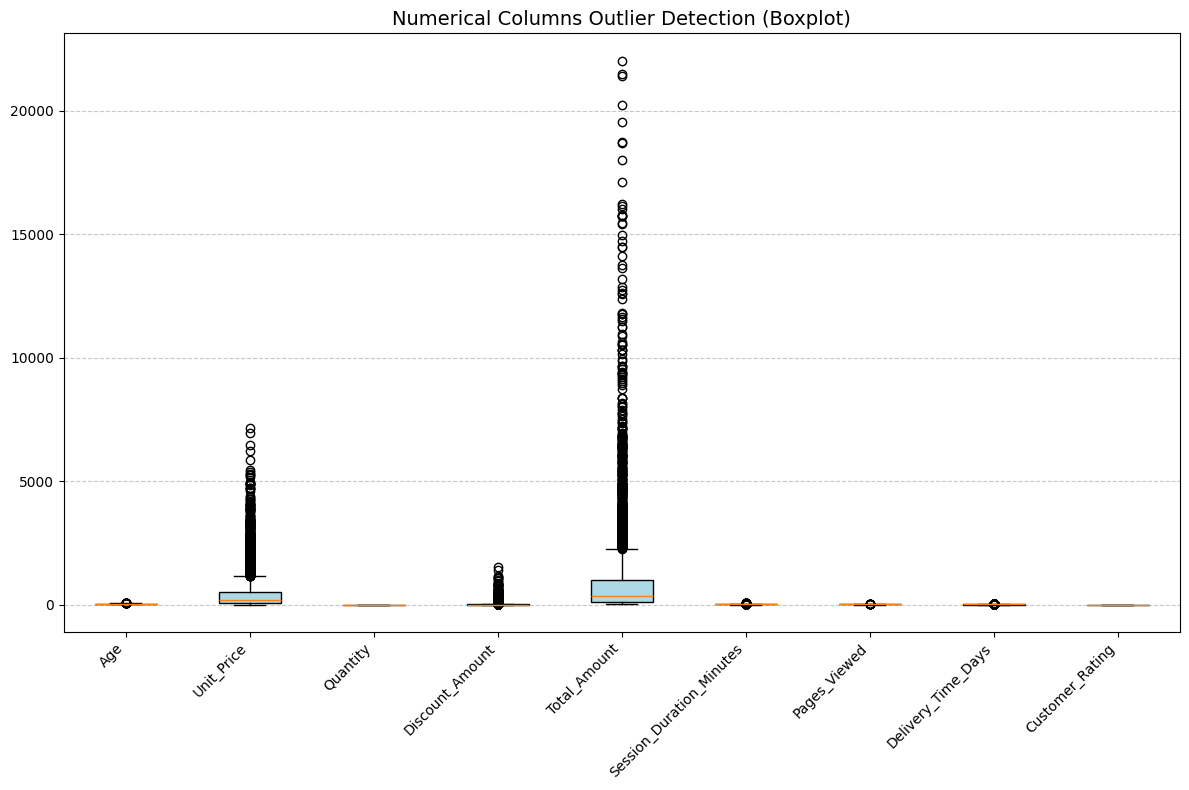

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Prepare data for plotting: extract values from each numeric column
plot_data = [df[col].values for col in num_cols]

# Draw boxplot
box = plt.boxplot(plot_data, labels=num_cols, patch_artist=True)

# Optional: color the boxes for better visualization
for patch in box['boxes']:
    patch.set_facecolor('lightblue')

plt.title("Numerical Columns Outlier Detection (Boxplot)", fontsize=14)
plt.xticks(rotation=45, ha='right')  # Rotate column names
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines for readability
plt.tight_layout()
plt.show()